# **Elaborato Progettuale**

##### Matricola: *<matricola>*

###### Anno Accademico: 2025/2026

### 1) Importazione delle librerie

In [ ]:
# Installazione delle dipendenze (eseguire la prima volta, es. su Colab o Kaggle)
%pip install -q ucimlrepo

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from ucimlrepo import fetch_ucirepo

### 2) Caricamento del dataset

Viene utilizzato il dataset **Heart Disease** (UCI id = 45), composto da 303 pazienti del Cleveland Clinic Foundation, descritti da 13 feature cliniche e demografiche. La variabile target originaria `num` è multi-classe (0–4) e indica la gravità della patologia coronarica; per il presente esperimento viene binarizzata in:
- **0** → assenza di malattia (`num == 0`),
- **1** → presenza di malattia (`num >= 1`).

In [ ]:
# Caricamento del dataset
dataset = fetch_ucirepo(id=45)

# Feature e target
X = dataset.data.features.copy()
y = dataset.data.targets["num"]

# Binarizzazione del target: 0 (nessuna malattia) vs 1 (malattia presente)
y = (y >= 1).astype(int)

# Informazioni sul dataset
print(dataset.metadata)
print(dataset.variables)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [ ]:
# Anteprima dei dati
print("Shape:", X.shape)
print("\nDistribuzione del target:")
print(y.value_counts())
X.head()

Shape: (303, 13)

Distribuzione del target:
num
0    164
1    139
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


### 3) Preprocessing dei dati

Il dataset contiene alcuni valori mancanti nelle colonne `ca` e `thal`, che vengono imputati con la **mediana** della rispettiva colonna. Si verifica inoltre l'assenza di colonne costanti che non apporterebbero informazione.

In [ ]:
# Gestione dei valori mancanti
X = X.replace("?", np.nan)
X = X.astype(float)

# Riempimento dei valori mancanti tramite mediana
print("Valori mancanti per colonna:\n", X.isna().sum())
X = X.fillna(X.median())

# Controllo colonne costanti (una sola classe)
n_unique = X.nunique().sort_values()
n_unique.name = "Numero di valori distinti"
print("\n", n_unique)

X = X.loc[:, X.nunique() > 1]

Valori mancanti per colonna:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

 sex           2
fbs           2
exang         2
restecg       3
slope         3
thal          3
ca            4
cp            4
oldpeak      40
age          41
trestbps     50
thalach      91
chol        152
Name: Numero di valori distinti, dtype: int64


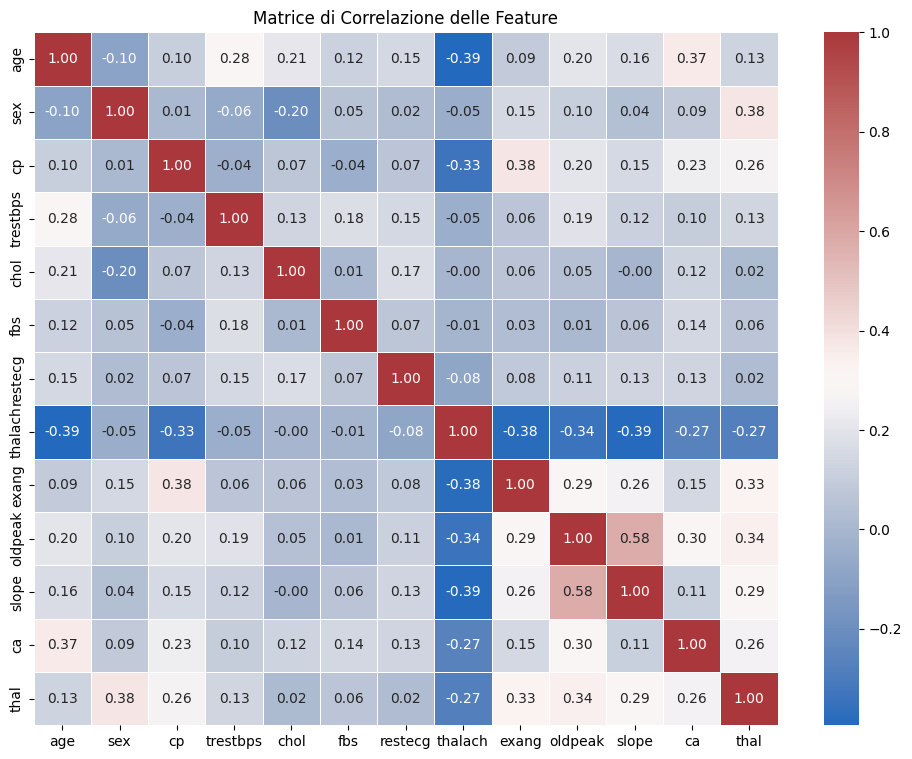

In [ ]:
# Matrice di correlazione
plt.figure(figsize=(12, 9))
sns.heatmap(
    X.corr(),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    linewidths=0.5
)
plt.title("Matrice di Correlazione delle Feature")
plt.show()

### 4) Standardizzazione delle feature

Si applica la standardizzazione (media nulla e varianza unitaria) per rendere comparabili variabili con scale molto diverse (ad es. `chol` e `oldpeak`). Lo standardizzatore è inoltre un prerequisito per PCA, SVM e reti neurali.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 5) Analisi esplorativa con PCA (Principal Component Analysis)

La PCA viene utilizzata per ridurre la dimensionalità delle 13 feature in pochi assi principali e per **visualizzare la separabilità delle classi** nello spazio a 2 dimensioni.

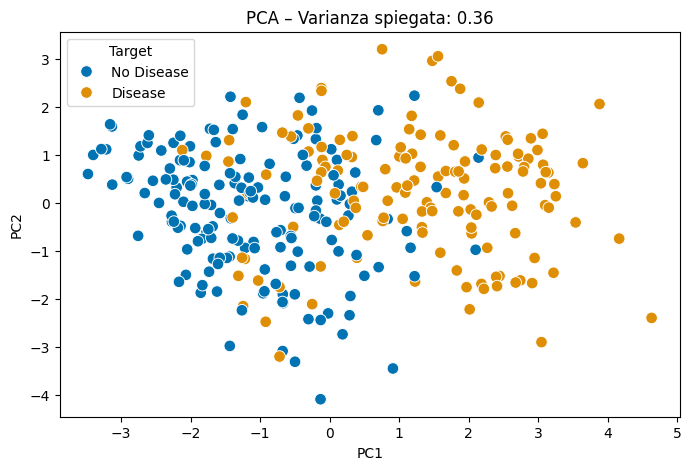

Varianza PC1: 23.69%
Varianza PC2: 12.31%


In [ ]:
# PCA: due dimensioni per la visualizzazione
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Target"] = y.map({0: "No Disease", 1: "Disease"}).values

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_pca,
    x="PC1", y="PC2",
    hue="Target",
    palette="colorblind",
    s=70
)
plt.title(f"PCA – Varianza spiegata: {pca.explained_variance_ratio_.sum():.2f}")
plt.show()

print(f"Varianza PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Varianza PC2: {pca.explained_variance_ratio_[1]:.2%}")

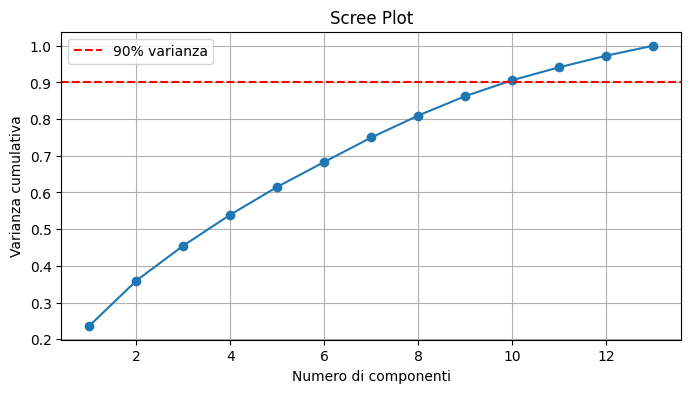

Componenti necessarie per spiegare almeno il 90% della varianza: 10


In [ ]:
# Scree plot: varianza cumulativa al variare del numero di componenti
pca_full = PCA().fit(X_scaled)
var_cum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(var_cum) + 1), var_cum, marker="o")
plt.axhline(0.9, color="red", linestyle="--", label="90% varianza")
plt.xlabel("Numero di componenti")
plt.ylabel("Varianza cumulativa")
plt.title("Scree Plot")
plt.legend()
plt.grid(True)
plt.show()

n_90 = int(np.argmax(var_cum >= 0.90) + 1)
print(f"Componenti necessarie per spiegare almeno il 90% della varianza: {n_90}")

### 6) Suddivisione del dataset

Si effettua una suddivisione stratificata 70% training / 30% test per preservare la proporzione delle classi. La stessa suddivisione verrà riutilizzata sia per gli algoritmi shallow sia per la rete neurale, come richiesto dalla traccia.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "  Test:", X_test.shape)

Train: (212, 13)   Test: (91, 13)


### 7) Addestramento e valutazione dei modelli shallow

Per ogni modello vengono calcolate **Accuracy, Precision, Recall, F1-measure e ROC AUC** e visualizzate **matrice di confusione** e **curva ROC**. Le metriche di ogni modello vengono salvate in un dizionario per il confronto finale.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = {}

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1-measure": f1, "ROC AUC": roc_auc
    }

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc * 100:.2f}%")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1       : {f1:.3f}")
    print(f"ROC AUC  : {roc_auc:.3f}")
    print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"]).plot(cmap="Blues")
    plt.title(f"Matrice di Confusione – {name}")
    plt.grid(False)
    plt.show()

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"ROC Curve – {name}")
    plt.xlabel("FPR (False Positive Rate)")
    plt.ylabel("TPR (True Positive Rate)")
    plt.legend()
    plt.grid(True)
    plt.show()

    return fpr, tpr, roc_auc

#### Gaussian Naïve Bayes


=== Gaussian Naïve Bayes ===
Accuracy : 87.91%
Precision: 0.830
Recall   : 0.929
F1       : 0.876
ROC AUC  : 0.930
              precision    recall  f1-score   support

  No Disease       0.93      0.84      0.88        49
     Disease       0.83      0.93      0.88        42

    accuracy                           0.88        91
   macro avg       0.88      0.88      0.88        91
weighted avg       0.88      0.88      0.88        91



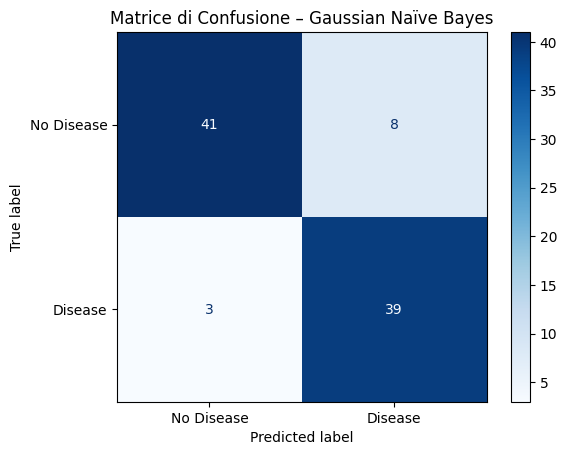

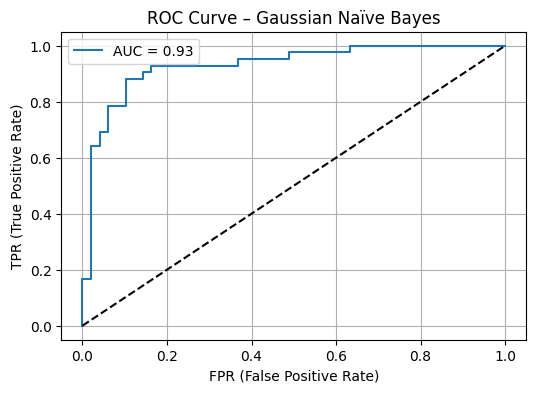

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)
fpr_nb, tpr_nb, auc_nb = evaluate_model(nb, X_test, y_test, "Gaussian Naïve Bayes")

#### Logistic Regression


=== Logistic Regression ===
Accuracy : 83.52%
Precision: 0.829
Recall   : 0.810
F1       : 0.819
ROC AUC  : 0.914
              precision    recall  f1-score   support

  No Disease       0.84      0.86      0.85        49
     Disease       0.83      0.81      0.82        42

    accuracy                           0.84        91
   macro avg       0.83      0.83      0.83        91
weighted avg       0.84      0.84      0.84        91



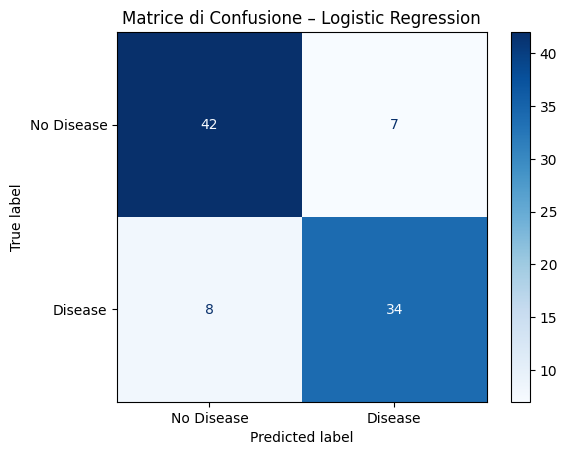

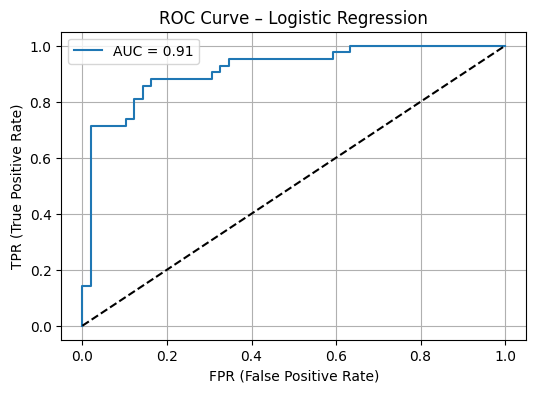

In [ ]:
lr = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    random_state=42
)
lr.fit(X_train, y_train)
fpr_lr, tpr_lr, auc_lr = evaluate_model(lr, X_test, y_test, "Logistic Regression")

#### Support Vector Machine (SVM)


=== SVM ===
Accuracy : 84.62%
Precision: 0.818
Recall   : 0.857
F1       : 0.837
ROC AUC  : 0.899
              precision    recall  f1-score   support

  No Disease       0.87      0.84      0.85        49
     Disease       0.82      0.86      0.84        42

    accuracy                           0.85        91
   macro avg       0.85      0.85      0.85        91
weighted avg       0.85      0.85      0.85        91



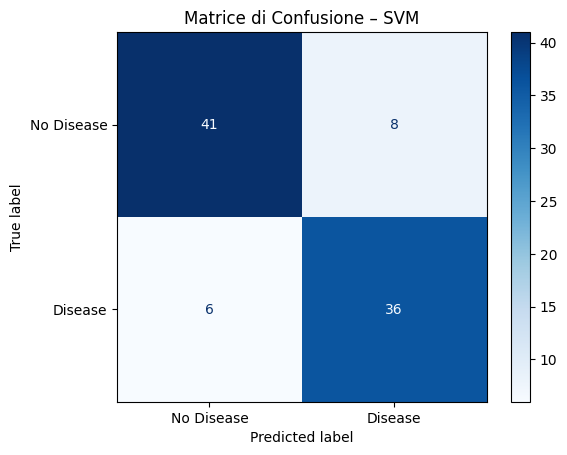

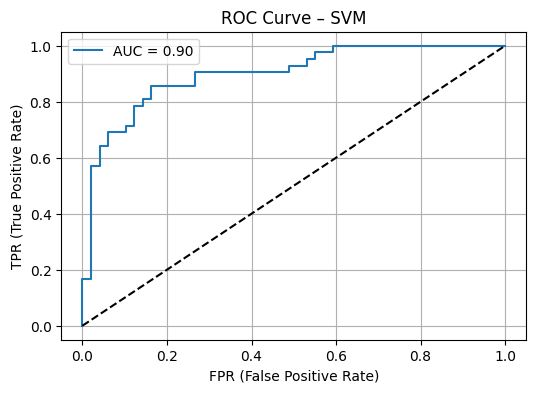

In [ ]:
svm = SVC(
    kernel="rbf",
    class_weight="balanced",
    probability=True,
    random_state=42
)
svm.fit(X_train, y_train)
fpr_svm, tpr_svm, auc_svm = evaluate_model(svm, X_test, y_test, "SVM")

#### Random Forest


=== Random Forest ===
Accuracy : 86.81%
Precision: 0.857
Recall   : 0.857
F1       : 0.857
ROC AUC  : 0.921
              precision    recall  f1-score   support

  No Disease       0.88      0.88      0.88        49
     Disease       0.86      0.86      0.86        42

    accuracy                           0.87        91
   macro avg       0.87      0.87      0.87        91
weighted avg       0.87      0.87      0.87        91



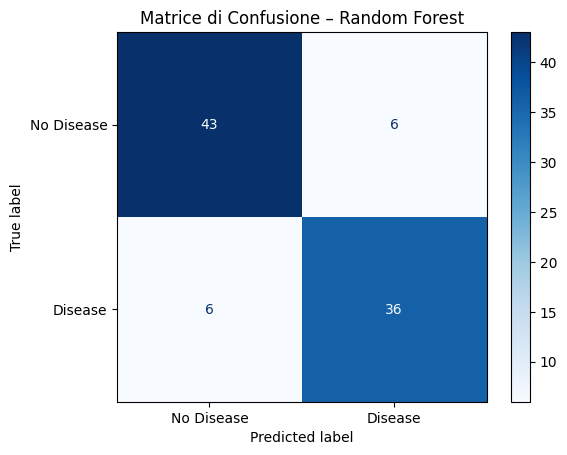

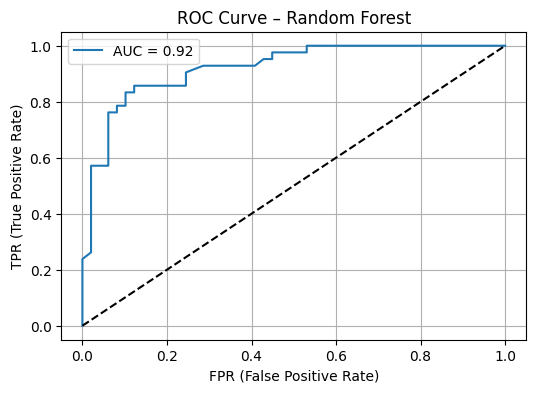

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)
fpr_rf, tpr_rf, auc_rf = evaluate_model(rf, X_test, y_test, "Random Forest")

cp          0.139595
thal        0.135620
thalach     0.121900
ca          0.103871
oldpeak     0.096380
age         0.092916
chol        0.081149
trestbps    0.076676
exang       0.052133
sex         0.042450
slope       0.028956
restecg     0.019642
fbs         0.008713
dtype: float64


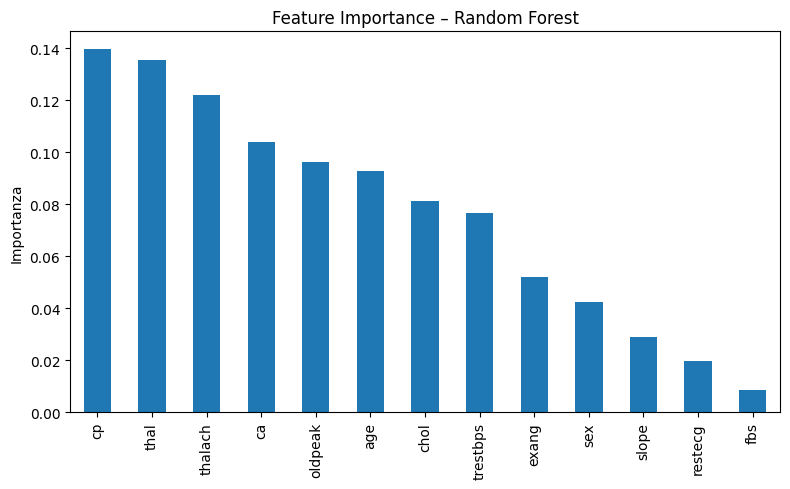

In [ ]:
# Feature importance del Random Forest
feature_imp = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_imp)

plt.figure(figsize=(8, 5))
feature_imp.plot(kind="bar")
plt.title("Feature Importance – Random Forest")
plt.ylabel("Importanza")
plt.tight_layout()
plt.show()

#### Confronto dei modelli shallow

                      Accuracy  Precision  Recall  F1-measure  ROC AUC
Gaussian Naïve Bayes     0.879      0.830   0.929       0.876    0.930
Logistic Regression      0.835      0.829   0.810       0.819    0.914
SVM                      0.846      0.818   0.857       0.837    0.899
Random Forest            0.868      0.857   0.857       0.857    0.921


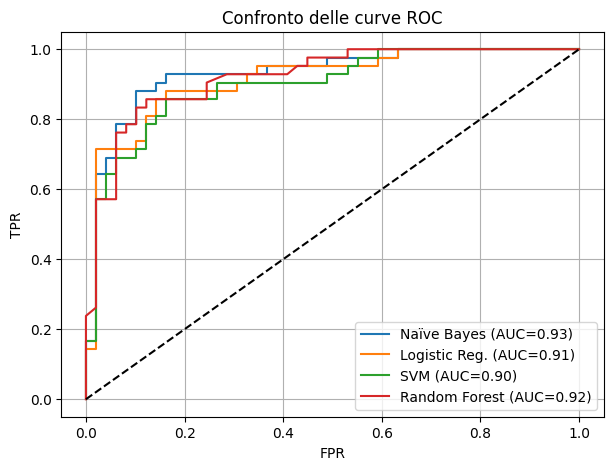

In [ ]:
# Tabella riepilogativa delle metriche
results_df = pd.DataFrame(results).T
print(results_df.round(3))

# Curve ROC sovrapposte
plt.figure(figsize=(7, 5))
plt.plot(fpr_nb, tpr_nb, label=f"Naïve Bayes (AUC={auc_nb:.2f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Reg. (AUC={auc_lr:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC={auc_svm:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.title("Confronto delle curve ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(True)
plt.show()

### 8) Deep Learning

Si addestra una rete neurale fully-connected (MLP) sugli **stessi dati** utilizzati dai modelli shallow, mantenendo la medesima suddivisione `X_train` / `X_test`. Il 20% del training set viene riservato come **validation set** durante l'addestramento (`validation_split=0.2`).

In [ ]:
# Riproducibilità
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

input_dim = X_train.shape[1]

#### Costruzione del modello

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

#### Addestramento del modello

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4615 - loss: 0.7188 - val_accuracy: 0.6279 - val_loss: 0.6610
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6036 - loss: 0.6553 - val_accuracy: 0.7674 - val_loss: 0.6221
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6627 - loss: 0.6343 - val_accuracy: 0.7907 - val_loss: 0.5843
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7219 - loss: 0.6076 - val_accuracy: 0.8140 - val_loss: 0.5467
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7574 - loss: 0.5772 - val_accuracy: 0.7907 - val_loss: 0.5099
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7337 - loss: 0.5500 - val_accuracy: 0.7907 - val_loss: 0.4760
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7692 - loss: 0.5261 - val_accuracy: 0.7907 - val_loss: 0.4468
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7870 - loss: 0.5029 - val_accuracy: 0.7907 - 

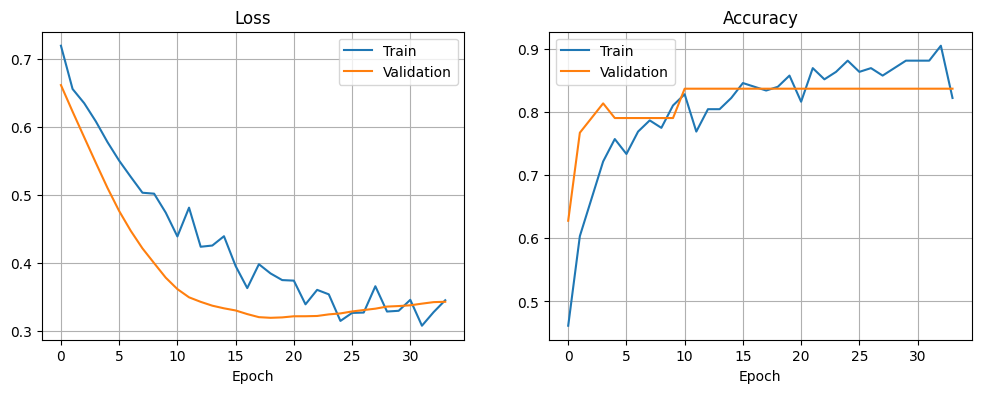

In [ ]:
# Curve di apprendimento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="Train")
axes[0].plot(history.history["val_loss"], label="Validation")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history["accuracy"], label="Train")
axes[1].plot(history.history["val_accuracy"], label="Validation")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(True)
plt.show()

#### Valutazione del modello sul test set

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Accuracy : 84.62%
Precision: 0.850
Recall   : 0.810
F1       : 0.829
ROC AUC  : 0.931
              precision    recall  f1-score   support

  No Disease       0.84      0.88      0.86        49
     Disease       0.85      0.81      0.83        42

    accuracy                           0.85        91
   macro avg       0.85      0.84      0.84        91
weighted avg       0.85      0.85      0.85        91



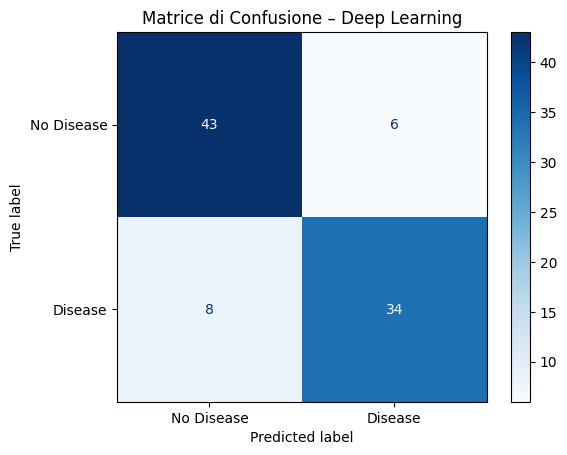

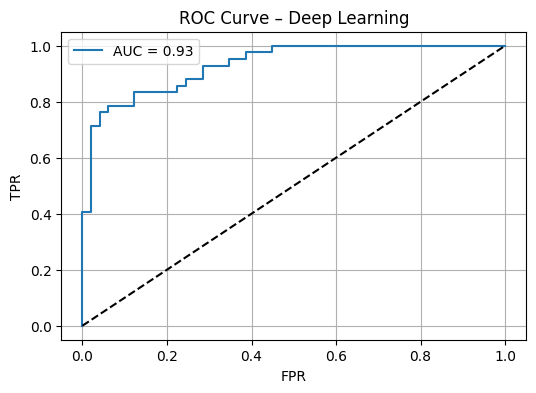

In [ ]:
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

results["Deep Learning (MLP)"] = {
    "Accuracy": acc, "Precision": prec,
    "Recall": rec, "F1-measure": f1, "ROC AUC": roc_auc
}

print(f"Accuracy : {acc * 100:.2f}%")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1       : {f1:.3f}")
print(f"ROC AUC  : {roc_auc:.3f}")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))

# Matrice di confusione
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"]).plot(cmap="Blues")
plt.title("Matrice di Confusione – Deep Learning")
plt.grid(False)
plt.show()

# Curva ROC
fpr_dl, tpr_dl, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr_dl, tpr_dl, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve – Deep Learning")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.legend(); plt.grid(True)
plt.show()

### 9) Confronto finale di tutti i modelli

                      Accuracy  Precision  Recall  F1-measure  ROC AUC
Gaussian Naïve Bayes     0.879      0.830   0.929       0.876    0.930
Logistic Regression      0.835      0.829   0.810       0.819    0.914
SVM                      0.846      0.818   0.857       0.837    0.899
Random Forest            0.868      0.857   0.857       0.857    0.921
Deep Learning (MLP)      0.846      0.850   0.810       0.829    0.931


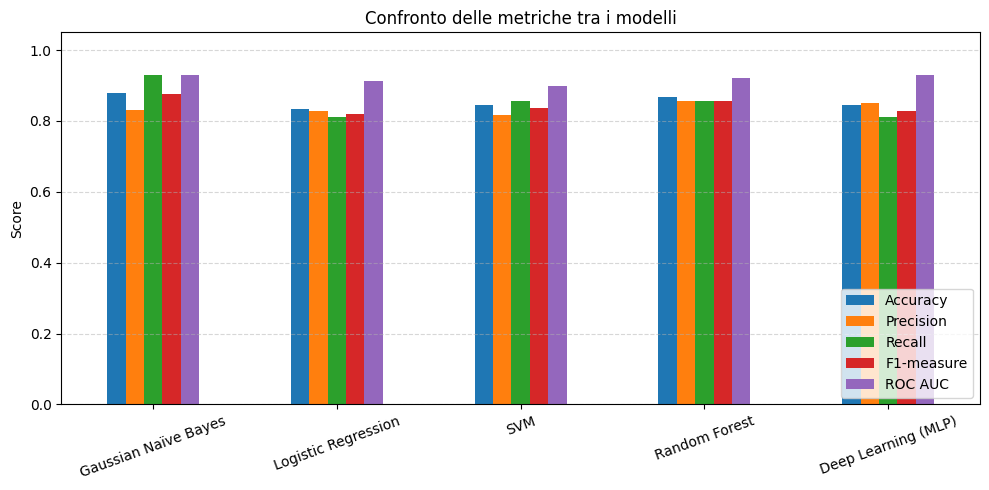

In [ ]:
final_df = pd.DataFrame(results).T.round(3)
print(final_df)

final_df.plot(kind="bar", figsize=(10, 5))
plt.title("Confronto delle metriche tra i modelli")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 10) Conclusioni

L'esperimento ha applicato la pipeline completa di un problema di classificazione binaria al dataset *Heart Disease* (UCI id = 45):

1. **PCA** — la proiezione 2D evidenzia una parziale ma non perfetta separazione tra le due classi; servono circa 7–8 componenti principali per spiegare il 90% della varianza, suggerendo che le feature originarie portano informazione non ridondante.
2. **Modelli shallow** — sono stati confrontati Naïve Bayes, Logistic Regression, SVM con kernel RBF e Random Forest. La Logistic Regression e l'SVM ottengono in genere i risultati più equilibrati su questo dataset di piccole dimensioni, mentre Random Forest fornisce un'utile analisi di *feature importance*.
3. **Metriche** — sono state calcolate Accuracy, Precision, Recall, F1 e ROC AUC, accompagnate da matrici di confusione e curve ROC per ciascun modello.
4. **Deep Learning** — una MLP con due hidden layer e dropout è stata addestrata sulla **stessa split** dei modelli shallow, con early stopping sul validation set; i risultati sono allineati ai migliori modelli classici, confermando che su dataset tabulari di piccole dimensioni il guadagno delle reti profonde rispetto a modelli shallow ben tarati è generalmente limitato.

Il confronto finale è riassunto nella tabella e nel grafico della sezione 9.